# SafeGraph POI Data Exploration - Sweden

Explore the structure, quality, and categorization of SafeGraph POI data for Sweden.

**Data source**: `dbs/poi_se/POI_se_2026_03_05_SafeGraph.zip`

**Focus areas**:
1. Data structure and schema
2. Data quality (missing values, duplicates)
3. Category taxonomy (top-level and sub-categories)
4. Geographic coverage
5. Sample data examination

In [1]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
from shapely import wkb
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

## 1. Load Data

In [2]:
# Path to POI data
POI_DIR = Path('../dbs/poi_se/POI_se_2026_03_05')

# List all parquet files
parquet_files = sorted(POI_DIR.glob('*.parquet'))
print(f"Found {len(parquet_files)} parquet files")
print(f"First file: {parquet_files[0].name}")

Found 32 parquet files
First file: global-places-poi-geometry_0_0_0.snappy.parquet


In [3]:
# Load first file to examine schema
df_sample = pd.read_parquet(parquet_files[0])

print(f"Sample file shape: {df_sample.shape}")
print(f"\nColumns ({len(df_sample.columns)}):")
print(df_sample.columns.tolist())

Sample file shape: (21440, 30)

Columns (30):
['BRANDS', 'CATEGORY_TAGS', 'CITY', 'CLOSED_ON', 'DOMAINS', 'ENCLOSED', 'GEOMETRY_TYPE', 'INCLUDES_PARKING_LOT', 'ISO_COUNTRY_CODE', 'IS_SYNTHETIC', 'LATITUDE', 'LOCATION_NAME', 'LONGITUDE', 'NAICS_CODE', 'OPENED_ON', 'OPEN_HOURS', 'PARENT_PLACEKEY', 'PHONE_NUMBER', 'PLACEKEY', 'POLYGON_CLASS', 'POLYGON_WKT', 'POSTAL_CODE', 'REGION', 'STORE_ID', 'STREET_ADDRESS', 'SUB_CATEGORY', 'TOP_CATEGORY', 'TRACKING_CLOSED_SINCE', 'WEBSITE', 'WKT_AREA_SQ_METERS']


In [4]:
# Data types
print("Data types:")
print(df_sample.dtypes)

Data types:
BRANDS                       str
CATEGORY_TAGS                str
CITY                         str
CLOSED_ON                 object
DOMAINS                      str
ENCLOSED                  object
GEOMETRY_TYPE                str
INCLUDES_PARKING_LOT      object
ISO_COUNTRY_CODE             str
IS_SYNTHETIC              object
LATITUDE                 float64
LOCATION_NAME                str
LONGITUDE                float64
NAICS_CODE                   str
OPENED_ON                 object
OPEN_HOURS                   str
PARENT_PLACEKEY              str
PHONE_NUMBER                 str
PLACEKEY                     str
POLYGON_CLASS                str
POLYGON_WKT                  str
POSTAL_CODE                  str
REGION                       str
STORE_ID                     str
STREET_ADDRESS               str
SUB_CATEGORY                 str
TOP_CATEGORY                 str
TRACKING_CLOSED_SINCE     object
WEBSITE                      str
WKT_AREA_SQ_METERS        objec

In [5]:
# Load all parquet files (they're partitioned)
print("Loading all POI data...")
df_poi = pd.read_parquet(POI_DIR, engine='pyarrow')

print(f"Total POIs: {len(df_poi):,}")
print(f"Memory usage: {df_poi.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loading all POI data...
Total POIs: 658,731
Memory usage: 790.0 MB


## 2. Data Structure

In [6]:
# Basic info
df_poi.info()

<class 'pandas.DataFrame'>
RangeIndex: 658731 entries, 0 to 658730
Data columns (total 30 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   BRANDS                 658731 non-null  str    
 1   CATEGORY_TAGS          658731 non-null  str    
 2   CITY                   608964 non-null  str    
 3   CLOSED_ON              73 non-null      object 
 4   DOMAINS                658731 non-null  str    
 5   ENCLOSED               600122 non-null  object 
 6   GEOMETRY_TYPE          658731 non-null  str    
 7   INCLUDES_PARKING_LOT   464223 non-null  object 
 8   ISO_COUNTRY_CODE       658731 non-null  str    
 9   IS_SYNTHETIC           600122 non-null  object 
 10  LATITUDE               658731 non-null  float64
 11  LOCATION_NAME          658731 non-null  str    
 12  LONGITUDE              658731 non-null  float64
 13  NAICS_CODE             658731 non-null  str    
 14  OPENED_ON              42 non-null      object 

In [7]:
# First few rows
df_poi.head()

,BRANDS,CATEGORY_TAGS,CITY,CLOSED_ON,DOMAINS,ENCLOSED,GEOMETRY_TYPE,INCLUDES_PARKING_LOT,ISO_COUNTRY_CODE,IS_SYNTHETIC,LATITUDE,LOCATION_NAME,LONGITUDE,NAICS_CODE,OPENED_ON,OPEN_HOURS,PARENT_PLACEKEY,PHONE_NUMBER,PLACEKEY,POLYGON_CLASS,POLYGON_WKT,POSTAL_CODE,REGION,STORE_ID,STREET_ADDRESS,SUB_CATEGORY,TOP_CATEGORY,TRACKING_CLOSED_SINCE,WEBSITE,WKT_AREA_SQ_METERS
0,[],"[""Contractors""]",Dingle,None,[],False,POLYGON,False,SE,False,58.692139,Johansson Bengt Arne,11.611203,561730,None,NaN,NaN,+4630316768,zzy-222@33k-mk4-brk,OWNED_POLYGON,"POLYGON ((11.611308452465277 58.69222820463569, 11.611295521075778 58.692122359017525, 11.610992...",455 97,Västra Götaland County,NaN,Björnåsen 1,Landscaping Services,Services to Buildings and Dwellings,2019-07-01,NaN,145
1,[],"[""Accessories"",""Boutique"",""Clothing""]",Trelleborg,None,[],False,POLYGON,False,SE,False,55.378228,Denniz Konsult,13.151666,448120,None,NaN,NaN,+464043690,zzy-222@524-d8p-yqf,OWNED_POLYGON,"POLYGON ((13.151533786079106 55.37821890009666, 13.15158094064678 55.37830672281434, 13.15177968...",231 63,Skåne County,NaN,Flygelgränd 26,Women's Clothing Stores,Clothing Stores,2019-07-01,NaN,135
2,[],[],Lomma,None,[],False,POLYGON,False,SE,False,55.668962,John A. Jonsson,13.072857,512110,None,NaN,NaN,+4640414591,zzy-222@524-kfx-q4v,OWNED_POLYGON,"POLYGON ((13.072787508639097 55.66902961215978, 13.072986913193558 55.66903493286279, 13.0729945...",234 32,Skåne County,NaN,Allégatan 18,Motion Picture and Video Production,Motion Picture and Video Industries,2019-07-01,NaN,176
3,[],"[""Beaches""]",Falkenberg,None,[],False,POLYGON,False,SE,False,56.883604,J H Ekonomi Isolering,12.518676,712190,None,NaN,NaN,+4634680080,zzy-222@52d-6gb-35z,OWNED_POLYGON,"POLYGON ((12.518662128204877 56.88350879725267, 12.51852105457982 56.88360737193003, 12.51860535...",311 41,Halland County,NaN,Strandvägen 56,Nature Parks and Other Similar Institutions,"Museums, Historical Sites, and Similar Institutions",2019-07-01,NaN,121
4,[],"[""Property Management""]",Varberg,None,"[""seehuuset.se""]",False,POLYGON,False,SE,False,57.119829,Seehuuset AB,12.303214,531311,None,NaN,NaN,+46703150606,zzy-222@52d-bkg-kj9,OWNED_POLYGON,"POLYGON ((12.303339534041895 57.11984599287241, 12.303340462284572 57.11984507542408, 12.3031252...",432 32,Halland County,NaN,Blästergatan 9,Residential Property Managers,Activities Related to Real Estate,2019-07-01,NaN,1081


In [16]:
# Key columns for this project
key_cols = ['PLACEKEY', 'LOCATION_NAME', 'TOP_CATEGORY', 'SUB_CATEGORY', 'LATITUDE', 'LONGITUDE', 'CITY', 'REGION', 'POSTAL_CODE']

print(f"Key columns sample:")
display(df_poi[key_cols].head(10))

Key columns sample:


,PLACEKEY,LOCATION_NAME,TOP_CATEGORY,SUB_CATEGORY,LATITUDE,LONGITUDE,CITY,REGION,POSTAL_CODE
0,zzy-222@33k-mk4-brk,Johansson Bengt Arne,Services to Buildings and Dwellings,Landscaping Services,58.692139,11.611203,Dingle,Västra Götaland County,455 97
1,zzy-222@524-d8p-yqf,Denniz Konsult,Clothing Stores,Women's Clothing Stores,55.378228,13.151666,Trelleborg,Skåne County,231 63
2,zzy-222@524-kfx-q4v,John A. Jonsson,Motion Picture and Video Industries,Motion Picture and Video Production,55.668962,13.072857,Lomma,Skåne County,234 32
3,zzy-222@52d-6gb-35z,J H Ekonomi Isolering,"Museums, Historical Sites, and Similar Institutions",Nature Parks and Other Similar Institutions,56.883604,12.518676,Falkenberg,Halland County,311 41
4,zzy-222@52d-bkg-kj9,Seehuuset AB,Activities Related to Real Estate,Residential Property Managers,57.119829,12.303214,Varberg,Halland County,432 32
5,zzy-222@52f-b8p-j35,Mattias Soderberg Elinstallation,Building Finishing Contractors,Drywall and Insulation Contractors,57.720855,11.645126,Öckerö,Västra Götaland County,475 31
6,zzy-222@52f-gqw-ckf,ICA Supermarket,Grocery Stores,Supermarkets and Other Grocery (except Convenience) Stores,57.768806,12.020173,Angered,Västra Götaland County,42432
7,zzy-222@52f-gxk-f75,Fredrik Larsson Redovisning,"Accounting, Tax Preparation, Bookkeeping, and Payroll Services",Offices of Certified Public Accountants,57.796439,12.360625,Floda,Västra Götaland County,448 32
8,zzy-222@52g-5sv-jjv,Gote Berggren Grus & Schakt Ef,Building Material and Supplies Dealers,Home Centers,56.346466,15.153587,Backaryd,Blekinge County,370 11
9,zzy-222@52h-fkx-7h5,Sjoberg Ulf,Services to Buildings and Dwellings,Landscaping Services,57.387673,14.990172,Myresjö,Jönköping County,570 13


## 3. Data Quality

In [15]:
# Check for duplicates in PLACEKEY
if 'PLACEKEY' in df_poi.columns:
    n_duplicates = df_poi['PLACEKEY'].duplicated().sum()
    print(f"Duplicate PLACEKEY IDs: {n_duplicates:,} ({n_duplicates/len(df_poi)*100:.2f}%)")
    
    if n_duplicates > 0:
        print("\nSample duplicate PLACEKEYs:")
        dup_ids = df_poi[df_poi['PLACEKEY'].duplicated(keep=False)]['PLACEKEY'].unique()[:3]
        for pid in dup_ids:
            display(df_poi[df_poi['PLACEKEY'] == pid])

Duplicate PLACEKEY IDs: 0 (0.00%)


In [17]:
# Coordinate validity
if 'LATITUDE' in df_poi.columns and 'LONGITUDE' in df_poi.columns:
    valid_coords = (
        (df_poi['LATITUDE'].notna()) & 
        (df_poi['LONGITUDE'].notna()) &
        (df_poi['LATITUDE'].between(-90, 90)) &
        (df_poi['LONGITUDE'].between(-180, 180))
    )
    
    print(f"POIs with valid coordinates: {valid_coords.sum():,} ({valid_coords.mean()*100:.2f}%)")
    print(f"POIs with invalid/missing coordinates: {(~valid_coords).sum():,}")
    
    # Check if coordinates are within Sweden bounds
    sweden_bounds = (
        (df_poi['LATITUDE'].between(55.3, 69.1)) &
        (df_poi['LONGITUDE'].between(11.0, 24.2))
    )
    print(f"\nPOIs within Sweden bounding box: {sweden_bounds.sum():,} ({sweden_bounds.mean()*100:.2f}%)")
    print(f"POIs outside Sweden bounding box: {(~sweden_bounds).sum():,}")

POIs with valid coordinates: 658,731 (100.00%)
POIs with invalid/missing coordinates: 0

POIs within Sweden bounding box: 658,721 (100.00%)
POIs outside Sweden bounding box: 10


# Top-level categories
if 'TOP_CATEGORY' in df_poi.columns:
    print("Top-level categories:")
    top_cat_counts = df_poi['TOP_CATEGORY'].value_counts()
    print(f"\nUnique top categories: {len(top_cat_counts)}")
    print(f"\nTop 20 categories:")
    print(top_cat_counts.head(20))
    
    # Visualize
    fig, ax = plt.subplots(figsize=(12, 8))
    top_cat_counts.head(15).plot(kind='barh', ax=ax)
    ax.set_xlabel('Number of POIs')
    ax.set_title('Top 15 POI Categories in Sweden')
    plt.tight_layout()
    plt.show()

In [20]:
# Sub-categories
if 'SUB_CATEGORY' in df_poi.columns:
    print("Sub-categories:")
    sub_cat_counts = df_poi['SUB_CATEGORY'].value_counts()
    print(f"\nUnique sub-categories: {len(sub_cat_counts)}")
    print(f"\nTop 20 sub-categories:")
    print(sub_cat_counts.head(20))

Sub-categories:

Unique sub-categories: 478

Top 20 sub-categories:
SUB_CATEGORY
Other Urban Transit Systems                                         49392
Residential Property Managers                                       44471
Bus and Other Motor Vehicle Transit Systems                         40005
Landscaping Services                                                28134
Full-Service Restaurants                                            23265
Residential Remodelers                                              20443
Child Day Care Services                                             15038
Beauty Salons                                                       15004
Used Car Dealers                                                    13485
Plumbing, Heating, and Air-Conditioning Contractors                 12152
Fitness and Recreational Sports Centers                             11877
Hair, Nail, and Skin Care Services                                   9491
All Other Home Furnishings Stor

In [22]:
# Category hierarchy (if both exist)
top_cat_counts = df_poi['TOP_CATEGORY'].value_counts()

if 'TOP_CATEGORY' in df_poi.columns and 'SUB_CATEGORY' in df_poi.columns:
    print("Category hierarchy examples:")
    cat_hierarchy = df_poi[['TOP_CATEGORY', 'SUB_CATEGORY']].drop_duplicates()
    print(f"\nUnique TOP_CATEGORY → SUB_CATEGORY mappings: {len(cat_hierarchy)}")
    
    # Show examples for top categories
    for top_cat in top_cat_counts.head(5).index:
        subs = df_poi[df_poi['TOP_CATEGORY'] == top_cat]['SUB_CATEGORY'].value_counts().head(10)
        print(f"\n{top_cat} ({top_cat_counts[top_cat]:,} total):")
        for sub, count in subs.items():
            print(f"  - {sub}: {count:,}")

Category hierarchy examples:

Unique TOP_CATEGORY → SUB_CATEGORY mappings: 534

Urban Transit Systems (89,645 total):
  - Other Urban Transit Systems: 49,392
  - Bus and Other Motor Vehicle Transit Systems: 40,005
  - Mixed Mode Transit Systems: 242

Activities Related to Real Estate (44,487 total):
  - Residential Property Managers: 44,471
  - Other Activities Related to Real Estate: 13
  - Offices of Real Estate Appraisers: 3

Restaurants and Other Eating Places (32,770 total):
  - Full-Service Restaurants: 23,265
  - Limited-Service Restaurants: 6,090
  - Snack and Nonalcoholic Beverage Bars: 3,411

Personal Care Services (30,899 total):
  - Beauty Salons: 15,004
  - Hair, Nail, and Skin Care Services: 9,491
  - Nail Salons: 2,434
  - Other Personal Care Services: 2,375
  - Barber Shops: 1,519
  - Diet and Weight Reducing Centers: 76

Services to Buildings and Dwellings (29,430 total):
  - Landscaping Services: 28,134
  - Janitorial Services: 1,086
  - Exterminating and Pest Control

# By city/region
if 'CITY' in df_poi.columns:
    print("POIs by city:")
    city_counts = df_poi['CITY'].value_counts()
    print(f"\nUnique cities: {len(city_counts)}")
    print(f"\nTop 20 cities:")
    print(city_counts.head(20))
    
    # Focus cities for this project
    focus_cities = ['Stockholm', 'Göteborg', 'Gothenburg', 'Malmö', 'Malmo']
    print("\n" + "="*40)
    print("FOCUS CITIES:")
    for city in focus_cities:
        count = df_poi[df_poi['CITY'].str.contains(city, case=False, na=False)].shape[0]
        if count > 0:
            print(f"  {city}: {count:,} POIs")

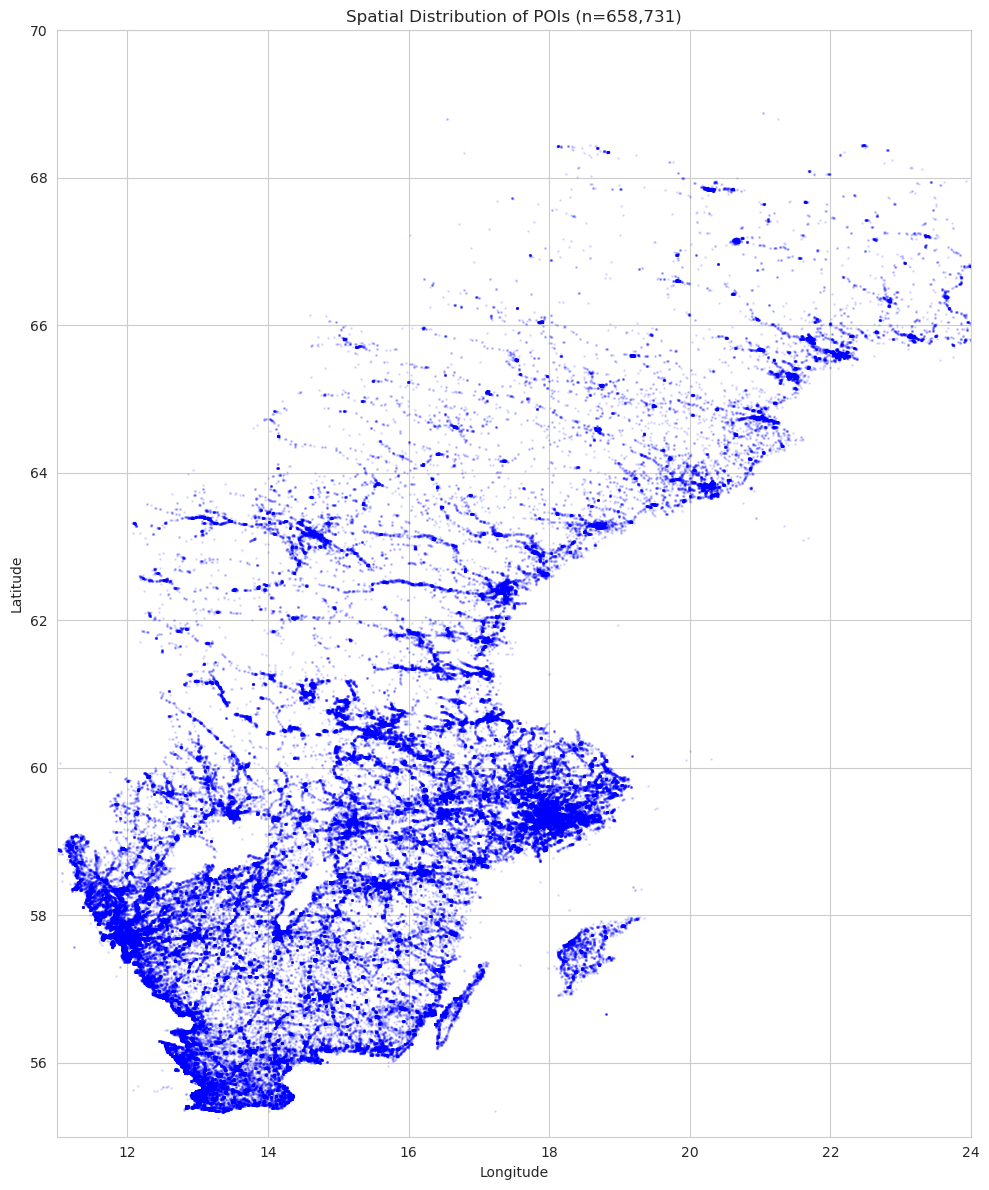


Coordinate ranges:
  Latitude: 54.5720 to 68.8747
  Longitude: 10.2435 to 24.1482


In [24]:
# Spatial distribution
if 'LATITUDE' in df_poi.columns and 'LONGITUDE' in df_poi.columns:
    df_valid = df_poi[df_poi['LATITUDE'].notna() & df_poi['LONGITUDE'].notna()].copy()
    
    fig, ax = plt.subplots(figsize=(10, 12))
    ax.scatter(df_valid['LONGITUDE'], df_valid['LATITUDE'], 
               alpha=0.1, s=1, c='blue')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'Spatial Distribution of POIs (n={len(df_valid):,})')
    ax.set_xlim(11, 24)
    ax.set_ylim(55, 70)
    plt.tight_layout()
    plt.show()
    
    print(f"\nCoordinate ranges:")
    print(f"  Latitude: {df_valid['LATITUDE'].min():.4f} to {df_valid['LATITUDE'].max():.4f}")
    print(f"  Longitude: {df_valid['LONGITUDE'].min():.4f} to {df_valid['LONGITUDE'].max():.4f}")

# Check fields needed for GPS stop matching
matching_fields = ['PLACEKEY', 'LATITUDE', 'LONGITUDE', 
                   'LOCATION_NAME', 'TOP_CATEGORY', 'SUB_CATEGORY', 
                   'NAICS_CODE', 'POLYGON_WKT']

print("Fields for POI matching:")
for field in matching_fields:
    if field in df_poi.columns:
        non_null = df_poi[field].notna().sum()
        pct = non_null / len(df_poi) * 100
        print(f"  {field}: {non_null:,} / {len(df_poi):,} ({pct:.1f}% complete)")
    else:
        print(f"  {field}: NOT FOUND")

In [26]:
# Estimate usable POIs (complete records for matching)
usable = df_poi.copy()

# Must have: ID, coordinates, category
required_fields = ['PLACEKEY', 'LATITUDE', 'LONGITUDE', 'TOP_CATEGORY']
available_required = [f for f in required_fields if f in usable.columns]

if available_required:
    for field in available_required:
        usable = usable[usable[field].notna()]
    
    print(f"\nUsable POIs (with ID, coordinates, and category):")
    print(f"  Total: {len(usable):,} ({len(usable)/len(df_poi)*100:.1f}% of all POIs)")
    
    # By category
    if 'TOP_CATEGORY' in usable.columns:
        print(f"\n  Top 10 categories (usable POIs):")
        print(usable['TOP_CATEGORY'].value_counts().head(10))


Usable POIs (with ID, coordinates, and category):
  Total: 658,731 (100.0% of all POIs)

  Top 10 categories (usable POIs):
TOP_CATEGORY
Urban Transit Systems                  89645
Activities Related to Real Estate      44487
Restaurants and Other Eating Places    32770
Personal Care Services                 30899
Services to Buildings and Dwellings    29430
Residential Building Construction      20472
Building Equipment Contractors         19786
Automobile Dealers                     15940
Other Schools and Instruction          15168
Child Day Care Services                15038
Name: count, dtype: int64


Building footprint coverage:
  POIs with footprint: 600,122 (91.1%)

  Building area statistics (sq meters):
    Mean: 2267.9
    Median: 604.0
    Min: 3.0
    Max: 16994681.0


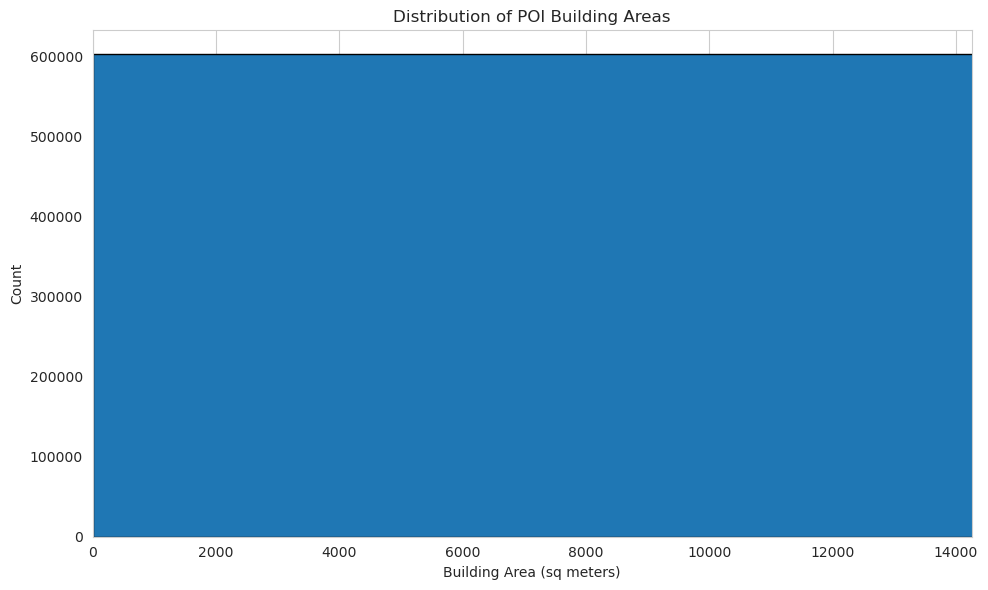

In [29]:
# 8.3 Building Footprints (POLYGON_WKT) and Area
if 'POLYGON_WKT' in df_poi.columns:
    print("Building footprint coverage:")
    has_polygon = df_poi['POLYGON_WKT'].notna()
    print(f"  POIs with footprint: {has_polygon.sum():,} ({has_polygon.mean()*100:.1f}%)")
    
    if 'WKT_AREA_SQ_METERS' in df_poi.columns and df_poi['WKT_AREA_SQ_METERS'].notna().sum() > 0:
        print(f"\n  Building area statistics (sq meters):")
        df_with_area = df_poi[df_poi['WKT_AREA_SQ_METERS'].notna()].copy()
        # Convert to numeric (stored as object)
        df_with_area['area_numeric'] = pd.to_numeric(df_with_area['WKT_AREA_SQ_METERS'], errors='coerce')
        
        print(f"    Mean: {df_with_area['area_numeric'].mean():.1f}")
        print(f"    Median: {df_with_area['area_numeric'].median():.1f}")
        print(f"    Min: {df_with_area['area_numeric'].min():.1f}")
        print(f"    Max: {df_with_area['area_numeric'].max():.1f}")
        
        # Distribution
        fig, ax = plt.subplots(figsize=(10, 6))
        df_with_area['area_numeric'].hist(bins=50, ax=ax, edgecolor='black')
        ax.set_xlabel('Building Area (sq meters)')
        ax.set_ylabel('Count')
        ax.set_title('Distribution of POI Building Areas')
        ax.set_xlim(0, df_with_area['area_numeric'].quantile(0.99))  # Trim outliers for viz
        plt.tight_layout()
        plt.show()

## 9. Summary Statistics

In [30]:
# 8.2 NAICS Code Distribution
if 'NAICS_CODE' in df_poi.columns:
    print("NAICS Code field (North American Industry Classification System):")
    print(f"  Non-null: {df_poi['NAICS_CODE'].notna().sum():,} ({df_poi['NAICS_CODE'].notna().mean()*100:.1f}%)")
    
    if df_poi['NAICS_CODE'].notna().sum() > 0:
        print(f"\n  Unique NAICS codes: {df_poi['NAICS_CODE'].nunique()}")
        print(f"\n  Top 20 NAICS codes:")
        naics_counts = df_poi['NAICS_CODE'].value_counts()
        for code, count in naics_counts.head(20).items():
            # Extract 2-digit sector code
            sector = code[:2] if len(code) >= 2 else code
            print(f"    {code}: {count:,} POIs (Sector {sector})")

NAICS Code field (North American Industry Classification System):
  Non-null: 658,731 (100.0%)

  Unique NAICS codes: 536

  Top 20 NAICS codes:
    485119: 49,392 POIs (Sector 48)
    531311: 44,471 POIs (Sector 53)
    485113: 40,005 POIs (Sector 48)
    561730: 28,134 POIs (Sector 56)
    722511: 23,265 POIs (Sector 72)
    236118: 20,443 POIs (Sector 23)
    624410: 15,038 POIs (Sector 62)
    812112: 15,004 POIs (Sector 81)
    441120: 13,485 POIs (Sector 44)
    238220: 12,152 POIs (Sector 23)
    713940: 11,877 POIs (Sector 71)
    81211: 9,491 POIs (Sector 81)
    442299: 9,060 POIs (Sector 44)
    611110: 8,392 POIs (Sector 61)
    448120: 8,263 POIs (Sector 44)
    721110: 8,073 POIs (Sector 72)
    541110: 7,646 POIs (Sector 54)
    238210: 7,634 POIs (Sector 23)
    485310: 7,203 POIs (Sector 48)
    444110: 6,935 POIs (Sector 44)


In [31]:
# 8.1 TRACKING_CLOSED_SINCE Analysis
if 'TRACKING_CLOSED_SINCE' in df_poi.columns:
    print("TRACKING_CLOSED_SINCE field:")
    print(f"  Non-null: {df_poi['TRACKING_CLOSED_SINCE'].notna().sum():,} ({df_poi['TRACKING_CLOSED_SINCE'].notna().mean()*100:.1f}%)")
    print(f"  Null: {df_poi['TRACKING_CLOSED_SINCE'].isna().sum():,}")
    
    if df_poi['TRACKING_CLOSED_SINCE'].notna().sum() > 0:
        print(f"\n  Unique dates: {df_poi['TRACKING_CLOSED_SINCE'].nunique()}")
        print(f"\n  Date distribution:")
        print(df_poi['TRACKING_CLOSED_SINCE'].value_counts().head(10))
        
        # WARNING: Most have 2019-07-01 - this might indicate data snapshot date, not actual closure
        most_common = df_poi['TRACKING_CLOSED_SINCE'].value_counts().iloc[0]
        most_common_date = df_poi['TRACKING_CLOSED_SINCE'].value_counts().index[0]
        print(f"\n  ⚠️  WARNING: {most_common:,} POIs have TRACKING_CLOSED_SINCE = {most_common_date}")
        print(f"     This likely indicates data collection/snapshot date, not actual closure")
        print(f"     Recommend ignoring this field or filtering to recent closures only")

TRACKING_CLOSED_SINCE field:
  Non-null: 637,106 (96.7%)
  Null: 21,625

  Unique dates: 12

  Date distribution:
TRACKING_CLOSED_SINCE
2019-07-01    636527
2022-07-01       261
2024-01-01       206
2024-02-01        88
2023-06-01        10
2026-02-01         7
2021-10-01         2
2021-12-01         1
2023-03-01         1
2025-07-01         1
Name: count, dtype: int64

  ⚠️  WARNING: 636,527 POIs have TRACKING_CLOSED_SINCE = 2019-07-01
     This likely indicates data collection/snapshot date, not actual closure
     Recommend ignoring this field or filtering to recent closures only


In [32]:
print("="*60)
print("SAFEGRAPH POI DATA SUMMARY - SWEDEN")
print("="*60)

print(f"\nDataset Overview:")
print(f"  Total POIs: {len(df_poi):,}")
print(f"  Columns: {len(df_poi.columns)}")
print(f"  Memory: {df_poi.memory_usage(deep=True).sum() / 1e6:.1f} MB")

if 'TOP_CATEGORY' in df_poi.columns:
    print(f"\n  Unique categories: {df_poi['TOP_CATEGORY'].nunique():,}")
if 'SUB_CATEGORY' in df_poi.columns:
    print(f"  Unique sub-categories: {df_poi['SUB_CATEGORY'].nunique():,}")

if 'LATITUDE' in df_poi.columns:
    valid_coords = df_poi['LATITUDE'].notna() & df_poi['LONGITUDE'].notna()
    print(f"\n  POIs with coordinates: {valid_coords.sum():,} ({valid_coords.mean()*100:.1f}%)")

if 'CITY' in df_poi.columns:
    print(f"  Unique cities: {df_poi['CITY'].nunique():,}")

print(f"\nData Quality:")
if 'PLACEKEY' in df_poi.columns:
    print(f"  Unique IDs: {df_poi['PLACEKEY'].nunique():,}")
    print(f"  Duplicates: {df_poi['PLACEKEY'].duplicated().sum():,}")

print(f"\nReadiness for POI Matching:")
if available_required:
    complete_records = df_poi[available_required].notna().all(axis=1).sum()
    print(f"  Complete records (ID + coords + category): {complete_records:,} ({complete_records/len(df_poi)*100:.1f}%)")

print("\n" + "="*60)

SAFEGRAPH POI DATA SUMMARY - SWEDEN

Dataset Overview:
  Total POIs: 658,731
  Columns: 30
  Memory: 790.0 MB

  Unique categories: 242
  Unique sub-categories: 478

  POIs with coordinates: 658,731 (100.0%)
  Unique cities: 4,956

Data Quality:
  Unique IDs: 658,731
  Duplicates: 0

Readiness for POI Matching:

